In [1]:
import pickle
import sys
from pathlib import Path
import numpy as np
sys.path.append("..")

import pandas as pd

In [2]:
# ============================================================
# CONFIGURATION - Update this path to your data directory
# ============================================================

DATA_DIR = Path('../pickle_files/syndrome_data_513')  # <-- [[5,1,3]] syndrome data

MEASUREMENTS_FILE = DATA_DIR / 'measurements.pkl'
GRAPH_FILE = DATA_DIR / 'graph.pkl'
GROUND_TRUTH_FILE = DATA_DIR / 'ground_truth.pkl'
INFERRED_PARAMETERS_FILE = DATA_DIR / 'inferred_params_independent.pkl'

# Verify files exist
print("Checking input files:")
for f in [MEASUREMENTS_FILE, GRAPH_FILE, GROUND_TRUTH_FILE, INFERRED_PARAMETERS_FILE]:
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}: {f.exists()}")

Checking input files:
  ✓ measurements.pkl: True
  ✓ graph.pkl: True
  ✓ ground_truth.pkl: True
  ✓ inferred_params_independent.pkl: True


In [3]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts for [[5,1,3]] code.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [4]:
# ============================================================
# LOAD PICKLE FILES
# ============================================================

with open(MEASUREMENTS_FILE, 'rb') as f:
    measurements = pickle.load(f)

with open(GRAPH_FILE, 'rb') as f:
    graph = pickle.load(f)

with open(GROUND_TRUTH_FILE, 'rb') as f:
    ground_truth = pickle.load(f)

# Try to load inferred parameters (may not exist yet)
try:
    with open(INFERRED_PARAMETERS_FILE, 'rb') as f:
        inferred_params_raw = pickle.load(f)
    # Normalize format: convert [px, py, pz] list to dict format
    inferred_params = {}
    for edge, rates in inferred_params_raw.items():
        if isinstance(rates, list):
            inferred_params[edge] = {'px': rates[0], 'py': rates[1], 'pz': rates[2], 'pi': 1.0 - sum(rates)}
        else:
            inferred_params[edge] = rates
    print(f"Loaded Inferred Parameters for {len(inferred_params)} edges")
except FileNotFoundError:
    inferred_params = None
    print("No inferred parameters file found - will use ground truth for predictions")

# Normalize ground truth format
ground_truth_normalized = {}
for edge, rates in ground_truth.items():
    if isinstance(rates, list):
        ground_truth_normalized[edge] = {'px': rates[0], 'py': rates[1], 'pz': rates[2], 'pi': 1.0 - sum(rates)}
    else:
        ground_truth_normalized[edge] = rates

print(f"Loaded {len(measurements)} syndrome measurements")
print(f"Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print(f"Loaded Ground Truth for {len(ground_truth_normalized)} edges")

Loaded Inferred Parameters for 7 edges
Loaded 17 syndrome measurements
Loaded graph with 6 nodes and 7 edges
Loaded Ground Truth for 7 edges


In [5]:
# ============================================================
# DISPLAY GROUND TRUTH / INFERRED PARAMETERS (px, py, pz, pi)
# ============================================================

# Use inferred params if available, otherwise use ground truth
params_to_display = inferred_params if inferred_params else ground_truth_normalized
params_source = "Inferred" if inferred_params else "Ground Truth"

params_data = []
for edge, rates in params_to_display.items():
    params_data.append({
        'Edge': str(edge),
        'px': rates['px'],
        'py': rates['py'],
        'pz': rates['pz'],
        'pi': rates['pi'],
        'total_error': rates['px'] + rates['py'] + rates['pz'],
    })

df_params = pd.DataFrame(params_data)

styled_params = (df_params
    .style
    .format({col: '{:.4f}' for col in ['px', 'py', 'pz', 'pi', 'total_error']})
    .set_caption(f'{params_source} Parameters Summary (px, py, pz, pi)')
    .background_gradient(subset=['total_error'], cmap='YlOrRd', vmin=0, vmax=0.1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
    ])
)

display(styled_params)

,Edge,px,py,pz,pi,total_error
0,"(0, 1)",0.0032,0.0029,0.0069,0.9870,0.0130
1,"(0, 3)",0.0067,0.0020,0.0055,0.9858,0.0142
2,"(1, 2)",0.0025,0.0022,0.0059,0.9895,0.0105
3,"(1, 4)",0.0085,0.0027,0.0078,0.9810,0.0190
4,"(2, 5)",0.0057,0.0022,0.0119,0.9803,0.0197
5,"(3, 4)",0.0072,0.0038,0.0086,0.9805,0.0195
6,"(4, 5)",0.0030,0.0018,0.0123,0.9829,0.0171


## [[5,1,3]] Code Syndrome Mapping

The [[5,1,3]] perfect code has 4 stabilizer generators:
- S1: XZZXI
- S2: IXZZX
- S3: XIXZZ
- S4: ZXIXZ

Each stabilizer measurement yields a single bit (0 or 1), giving a 4-bit syndrome with 16 possible outcomes.

**Syndrome calculation**: For a Pauli error E on qubit q, syndrome bit s_i = 1 iff E anticommutes with S_i.

**Anticommutation rules**:
- X anticommutes with Z (not I, X, Y)
- Y anticommutes with both X and Z
- Z anticommutes with X (not I, Y, Z)
- I commutes with everything

In [6]:
# ============================================================
# [[5,1,3]] STABILIZER SYNDROME MAPPING
# ============================================================
from typing import List, Tuple, Dict

# [[5,1,3]] stabilizers
STABILIZERS_513 = [
    "XZZXI",  # S1
    "IXZZX",  # S2
    "XIXZZ",  # S3
    "ZXIXZ",  # S4
]

def anticommutes(pauli1: str, pauli2: str) -> bool:
    """
    Check if two single-qubit Paulis anticommute.
    X anticommutes with Z, Y anticommutes with X and Z.
    """
    if pauli1 == 'I' or pauli2 == 'I':
        return False
    if pauli1 == pauli2:
        return False
    # X-Z, Z-X, X-Y, Y-X, Y-Z, Z-Y all anticommute
    return True


def compute_syndrome_513(error_type: str, qubit: int) -> int:
    """
    Compute the 4-bit syndrome for a single-qubit Pauli error on the [[5,1,3]] code.
    
    Args:
        error_type: 'I', 'X', 'Y', or 'Z'
        qubit: Qubit index (0-4)
    
    Returns:
        Integer syndrome (0-15) representing the 4-bit measurement outcome
    """
    if error_type == 'I':
        return 0
    
    syndrome = 0
    for stab_idx, stabilizer in enumerate(STABILIZERS_513):
        stab_pauli = stabilizer[qubit]
        if anticommutes(error_type, stab_pauli):
            syndrome |= (1 << stab_idx)  # Set bit stab_idx
    
    return syndrome


# Build syndrome lookup table
SYNDROME_TABLE_513 = {}
for error in ['I', 'X', 'Y', 'Z']:
    for qubit in range(5):
        syndrome = compute_syndrome_513(error, qubit)
        SYNDROME_TABLE_513[(error, qubit)] = syndrome

print("[[5,1,3]] Syndrome Table:")
print("-" * 50)
print(f"{'Error':<8} {'Qubit':<8} {'Syndrome (binary)':<20} {'Syndrome (int)'}")
print("-" * 50)
for (error, qubit), syndrome in SYNDROME_TABLE_513.items():
    print(f"{error:<8} {qubit:<8} {bin(syndrome)[2:].zfill(4):<20} {syndrome}")

[[5,1,3]] Syndrome Table:
--------------------------------------------------
Error    Qubit    Syndrome (binary)    Syndrome (int)
--------------------------------------------------
I        0        0000                 0
I        1        0000                 0
I        2        0000                 0
I        3        0000                 0
I        4        0000                 0
X        0        1000                 8
X        1        0001                 1
X        2        0011                 3
X        3        0110                 6
X        4        1100                 12
Y        0        1101                 13
Y        1        1011                 11
Y        2        0111                 7
Y        3        1111                 15
Y        4        1110                 14
Z        0        0101                 5
Z        1        1010                 10
Z        2        0100                 4
Z        3        1001                 9
Z        4        0010           

In [7]:
# ============================================================
# PAULI COMPOSITION (same as before - code-agnostic)
# ============================================================

def pauli_compose(state: np.ndarray, edge_probs: np.ndarray) -> np.ndarray:
    """
    Compose accumulated Pauli state with edge's Pauli channel.
    
    Pauli multiplication rules (ignoring phase):
    - I*I=I, X*X=I, Y*Y=I, Z*Z=I
    - I*X=X, X*I=X, Y*Z=X, Z*Y=X
    - I*Y=Y, Y*I=Y, X*Z=Y, Z*X=Y
    - I*Z=Z, Z*I=Z, X*Y=Z, Y*X=Z
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution
        edge_probs: [pX, pY, pZ] edge error probabilities (pI computed as 1 - sum)
    
    Returns:
        New [pI, pX, pY, pZ] state after applying edge channel
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    e_px, e_py, e_pz = edge_probs[0], edge_probs[1], edge_probs[2]
    e_pi = 1.0 - e_px - e_py - e_pz
    
    # Apply Pauli composition rules
    new_pi = pi*e_pi + px*e_px + py*e_py + pz*e_pz
    new_px = pi*e_px + px*e_pi + py*e_pz + pz*e_py
    new_py = pi*e_py + py*e_pi + px*e_pz + pz*e_px
    new_pz = pi*e_pz + pz*e_pi + px*e_py + py*e_px
    
    return np.array([new_pi, new_px, new_py, new_pz])


def get_edge_pauli_probs(edge: Tuple[int, int], params: Dict) -> np.ndarray:
    """
    Get Pauli error probabilities [px, py, pz] for an edge.
    
    Args:
        edge: Edge tuple (may need sorting)
        params: Parameter dictionary with {edge: {'px', 'py', 'pz', 'pi'}}
    
    Returns:
        np.array([px, py, pz])
    """
    edge_key = tuple(sorted(edge))
    edge_data = params.get(edge_key)
    
    if edge_data is None:
        raise KeyError(f"No parameters for edge {edge_key}")
    
    return np.array([edge_data['px'], edge_data['py'], edge_data['pz']])


print("Pauli composition functions defined.")

Pauli composition functions defined.


In [8]:
# ============================================================
# [[5,1,3]] SYNDROME PREDICTION
# ============================================================

def pauli_to_syndrome_513(state: np.ndarray) -> np.ndarray:
    """
    Map accumulated Pauli state to 16-element syndrome distribution for [[5,1,3]] code.
    
    For the [[5,1,3]] code:
    - 5 qubits, 4 stabilizers → 16 possible syndromes
    - Each single-qubit Pauli error maps to a specific syndrome
    - We assume errors are i.i.d. across the 5 qubits with the same Pauli distribution
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution per qubit
    
    Returns:
        16-element syndrome probability distribution
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    
    # Initialize syndrome distribution
    syndrome_probs = np.zeros(16)
    
    # For each qubit and each possible error type, accumulate syndrome probabilities
    # We use the approximation that at most one error occurs (valid for small error rates)
    
    # Probability of no error on any qubit (approximately)
    # P(no error) ≈ pi^5 for i.i.d. errors
    p_no_error = pi ** 5
    syndrome_probs[0] = p_no_error
    
    # Single-qubit errors
    for qubit in range(5):
        for error, p_error in [('X', px), ('Y', py), ('Z', pz)]:
            # Probability of this specific error on this qubit, no errors elsewhere
            # P(error on qubit q) ≈ p_error * pi^4
            p_single = p_error * (pi ** 4)
            syndrome = SYNDROME_TABLE_513[(error, qubit)]
            syndrome_probs[syndrome] += p_single
    
    # Normalize to ensure probabilities sum to 1
    # (accounts for multi-qubit errors we're ignoring)
    total = np.sum(syndrome_probs)
    if total > 0:
        syndrome_probs = syndrome_probs / total
    
    return syndrome_probs


def pauli_to_syndrome_513_exact(state: np.ndarray) -> np.ndarray:
    """
    Exact computation of syndrome distribution for [[5,1,3]] code.
    
    Enumerates all 4^5 = 1024 possible error configurations and computes
    their syndromes exactly. More accurate but slower.
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution per qubit
    
    Returns:
        16-element syndrome probability distribution
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    pauli_probs = {'I': pi, 'X': px, 'Y': py, 'Z': pz}
    paulis = ['I', 'X', 'Y', 'Z']
    
    syndrome_probs = np.zeros(16)
    
    # Enumerate all 4^5 error configurations
    for e0 in paulis:
        for e1 in paulis:
            for e2 in paulis:
                for e3 in paulis:
                    for e4 in paulis:
                        # Compute probability of this configuration
                        prob = pauli_probs[e0] * pauli_probs[e1] * pauli_probs[e2] * pauli_probs[e3] * pauli_probs[e4]
                        
                        # Compute syndrome (XOR of individual syndromes)
                        syndrome = 0
                        for q, e in enumerate([e0, e1, e2, e3, e4]):
                            syndrome ^= SYNDROME_TABLE_513[(e, q)]
                        
                        syndrome_probs[syndrome] += prob
    
    return syndrome_probs


def predict_syndrome_513(path_edges: List[Tuple[int, int]],
                         params: Dict,
                         num_shots: int = 4096,
                         exact: bool = True) -> np.ndarray:
    """
    Predict syndrome histogram for [[5,1,3]] code using Pauli channel composition.
    
    1. Start with identity state [1, 0, 0, 0] (no errors)
    2. Compose Pauli channels for each edge in the path
    3. Convert final Pauli state to syndrome distribution
    
    Args:
        path_edges: List of edge tuples in the path
        params: Dict mapping edge -> {px, py, pz, pi}
        num_shots: Number of shots for histogram scaling
        exact: If True, use exact 4^5 enumeration; if False, use approximation
    
    Returns:
        Predicted histogram (16 elements)
    """
    # Start with identity (no error)
    state = np.array([1.0, 0.0, 0.0, 0.0])  # [pI, pX, pY, pZ]
    
    # Compose Pauli channels for each edge
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, params)
        state = pauli_compose(state, edge_probs)
    
    # Convert to syndrome distribution
    if exact:
        syndrome_probs = pauli_to_syndrome_513_exact(state)
    else:
        syndrome_probs = pauli_to_syndrome_513(state)
    
    # Scale to histogram counts
    histogram = syndrome_probs * num_shots
    
    return histogram.astype(np.float32)


print("[[5,1,3]] syndrome prediction functions defined.")

[[5,1,3]] syndrome prediction functions defined.


In [9]:
# ============================================================
# DISPLAY SYNDROME MEASUREMENTS (16 outcomes)
# ============================================================

# Generate syndrome labels (0000 through 1111)
SYNDROME_LABELS = [format(i, '04b') for i in range(16)]

measurements_data = []
for measure in measurements:
    hist_norm = measure.histogram / np.sum(measure.histogram)
    row = {
        'Path': str(measure.path_edges),
        'Code': measure.code_type,
        'P(0000)': hist_norm[0],  # No error syndrome
        'P(error)': 1.0 - hist_norm[0],  # Total error probability
    }
    measurements_data.append(row)

df_measurements = pd.DataFrame(measurements_data)

styled_measurements = (df_measurements
    .style
    .format({'P(0000)': '{:.4f}', 'P(error)': '{:.4f}'})
    .set_caption(f'[[5,1,3]] Syndrome Measurements Summary ({len(measurements)} total)')
    .background_gradient(subset=['P(0000)'], cmap='Greens', vmin=0.8, vmax=1.0)
    .background_gradient(subset=['P(error)'], cmap='Reds', vmin=0, vmax=0.2)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_measurements)

,Path,Code,P(0000),P(error)
0,"[(0, 1)]",513,0.9128,0.0872
1,"[(0, 1), (1, 2)]",513,0.9119,0.0881
2,"[(0, 3)]",513,0.9116,0.0884
3,"[(0, 1), (1, 4)]",513,0.8337,0.1663
4,"[(0, 3), (3, 4)]",513,0.8496,0.1504
5,"[(1, 2)]",513,0.9336,0.0664
6,"[(1, 0), (0, 3)]",513,0.9050,0.0950
7,"[(1, 4), (4, 3)]",513,0.8894,0.1106
8,"[(1, 4)]",513,0.8728,0.1272
9,"[(1, 2), (2, 5)]",513,0.8711,0.1289


In [10]:
# ============================================================
# COMPUTE PREDICTED VS OBSERVED SYNDROME HISTOGRAMS
# ============================================================

# Use inferred params if available, otherwise use ground truth
params_for_prediction = inferred_params if inferred_params else ground_truth_normalized
params_source = "Inferred" if inferred_params else "Ground Truth"

# Estimate num_shots from first measurement
NUM_SHOTS = int(np.sum(measurements[0].histogram))

comparison_results = []

for measurement in measurements:
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    # Predict histogram using Pauli composition
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    # Normalize both to probabilities
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    # Calculate accumulated Pauli state for this path
    state = np.array([1.0, 0.0, 0.0, 0.0])
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, params_for_prediction)
        state = pauli_compose(state, edge_probs)
    
    comparison_results.append({
        'Path': str(path_edges),
        'Hops': len(path_edges),
        'pI': state[0],
        'pX': state[1],
        'pY': state[2],
        'pZ': state[3],
        'Pred P(0000)': predicted_probs[0],
        'Obs P(0000)': observed_probs[0],
        'Diff': observed_probs[0] - predicted_probs[0],
    })

df_comparison = pd.DataFrame(comparison_results)

# Style the DataFrame
def color_diff(val):
    """Color differences: green for small, red for large."""
    color = '#c8e6c9' if abs(val) < 0.02 else '#ffcdd2' if abs(val) > 0.05 else '#fff9c4'
    return f'background-color: {color}; color: black'

styled_comparison = (df_comparison
    .style
    .format({
        'pI': '{:.4f}', 'pX': '{:.4f}', 'pY': '{:.4f}', 'pZ': '{:.4f}',
        'Pred P(0000)': '{:.4f}', 'Obs P(0000)': '{:.4f}', 'Diff': '{:+.4f}'
    })
    .set_caption(f'Predicted vs Observed Syndrome (using {params_source} parameters)')
    .map(color_diff, subset=['Diff'])
    .background_gradient(subset=['Pred P(0000)', 'Obs P(0000)'], cmap='Blues', vmin=0.8, vmax=1.0)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_comparison)

,Path,Hops,pI,pX,pY,pZ,Pred P(0000),Obs P(0000),Diff
0,"[(0, 1)]",1,0.9870,0.0032,0.0029,0.0069,0.9369,0.9128,-0.0240
1,"[(0, 1), (1, 2)]",2,0.9767,0.0056,0.0050,0.0126,0.8888,0.9119,+0.0231
2,"[(0, 3)]",1,0.9858,0.0067,0.0020,0.0055,0.9309,0.9116,-0.0193
3,"[(0, 1), (1, 4)]",2,0.9684,0.0116,0.0056,0.0145,0.8515,0.8337,-0.0178
4,"[(0, 3), (3, 4)]",2,0.9666,0.0137,0.0058,0.0139,0.8439,0.8496,+0.0057
5,"[(1, 2)]",1,0.9895,0.0025,0.0022,0.0059,0.9484,0.9336,-0.0148
6,"[(1, 0), (0, 3)]",2,0.9731,0.0098,0.0049,0.0123,0.8724,0.9050,+0.0326
7,"[(1, 4), (4, 3)]",2,0.9619,0.0154,0.0065,0.0162,0.8237,0.8894,+0.0657
8,"[(1, 4)]",1,0.9810,0.0085,0.0027,0.0078,0.9085,0.8728,-0.0357
9,"[(1, 2), (2, 5)]",2,0.9701,0.0081,0.0043,0.0175,0.8591,0.8711,+0.0120


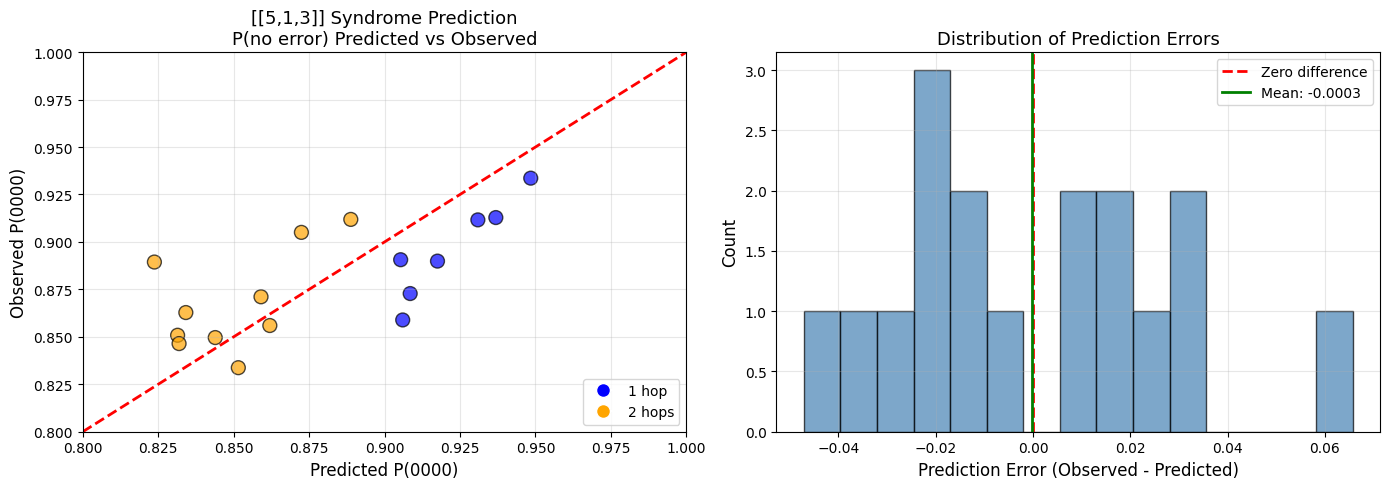


Prediction Quality Summary:
  Mean difference: -0.0003
  Std deviation:   0.0290
  Max absolute:    0.0657
  Correlation:     0.7074


In [11]:
# ============================================================
# VISUALIZE PREDICTIONS: P(0000) Predicted vs Observed
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot of predicted vs observed P(0000)
ax1 = axes[0]
colors = ['blue' if h == 1 else 'orange' if h == 2 else 'green' for h in df_comparison['Hops']]
scatter = ax1.scatter(df_comparison['Pred P(0000)'], df_comparison['Obs P(0000)'], 
                      c=colors, s=100, alpha=0.7, edgecolors='black')
ax1.plot([0.8, 1], [0.8, 1], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Predicted P(0000)', fontsize=12)
ax1.set_ylabel('Observed P(0000)', fontsize=12)
ax1.set_title('[[5,1,3]] Syndrome Prediction\nP(no error) Predicted vs Observed', fontsize=13)
ax1.set_xlim(0.8, 1.0)
ax1.set_ylim(0.8, 1.0)
ax1.grid(True, alpha=0.3)

# Add legend for hop colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='1 hop'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='2 hops'),
]
ax1.legend(handles=legend_elements, loc='lower right')

# Plot 2: Difference distribution
ax2 = axes[1]
ax2.hist(df_comparison['Diff'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax2.axvline(x=df_comparison['Diff'].mean(), color='green', linestyle='-', linewidth=2, 
            label=f'Mean: {df_comparison["Diff"].mean():.4f}')
ax2.set_xlabel('Prediction Error (Observed - Predicted)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Prediction Errors', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPrediction Quality Summary:")
print(f"  Mean difference: {df_comparison['Diff'].mean():+.4f}")
print(f"  Std deviation:   {df_comparison['Diff'].std():.4f}")
print(f"  Max absolute:    {df_comparison['Diff'].abs().max():.4f}")
corr = np.corrcoef(df_comparison['Pred P(0000)'], df_comparison['Obs P(0000)'])[0, 1]
print(f"  Correlation:     {corr:.4f}")

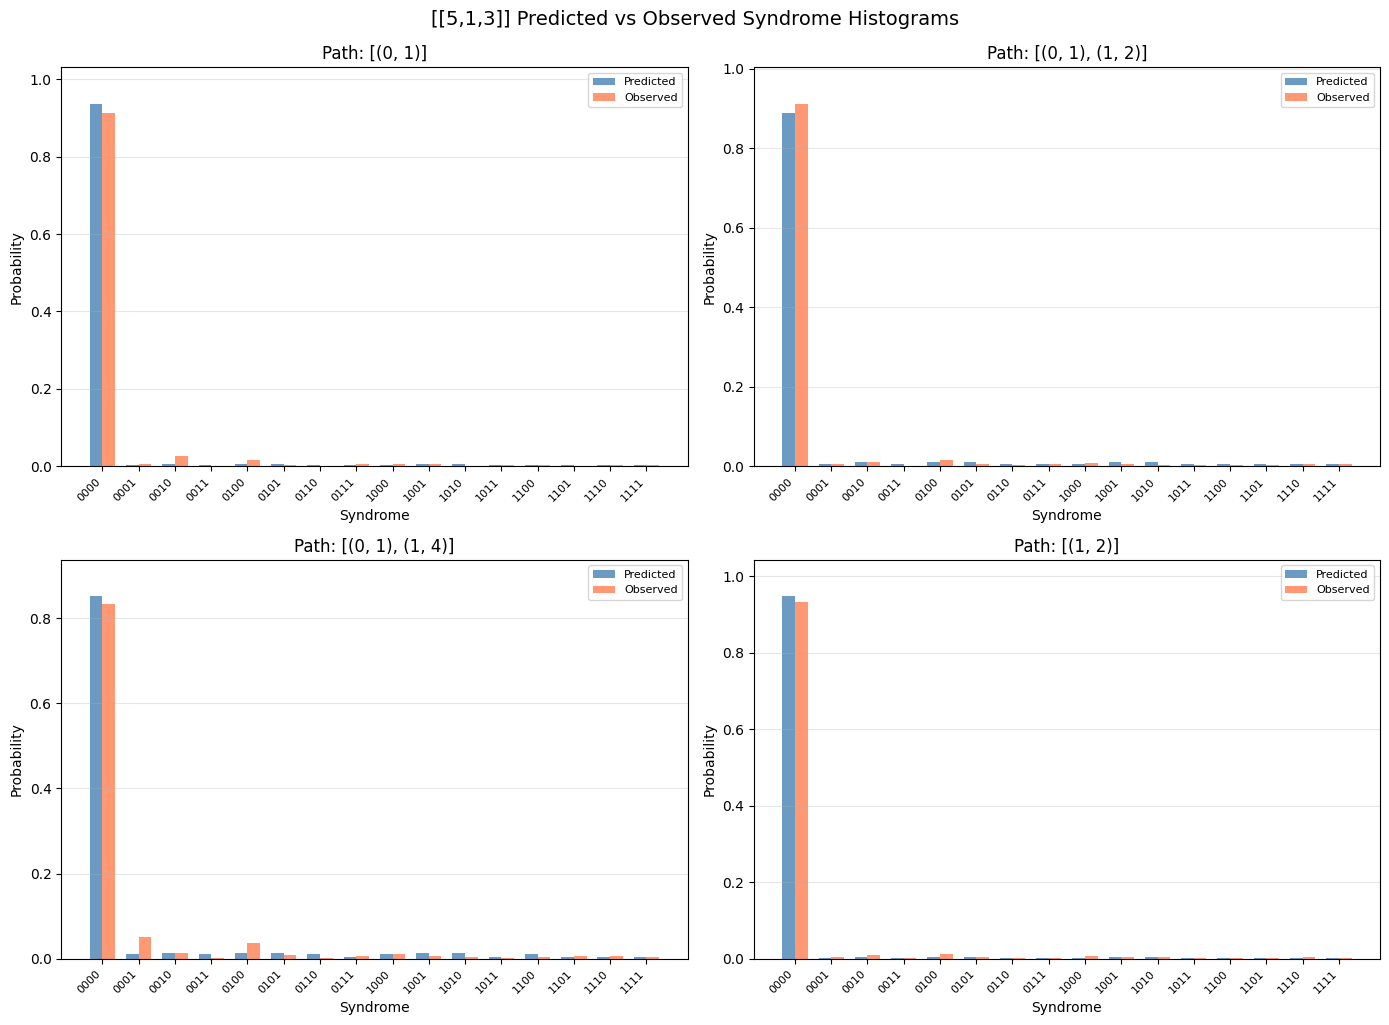

In [12]:
# ============================================================
# FULL 16-BIN HISTOGRAM COMPARISON
# ============================================================

# Select a few representative paths for detailed comparison
sample_indices = [0, 1, 3, 5] if len(measurements) > 5 else list(range(min(4, len(measurements))))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(16)
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    bars1 = ax.bar(x - width/2, predicted_probs, width, label='Predicted', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, observed_probs, width, label='Observed', color='coral', alpha=0.8)
    
    ax.set_xlabel('Syndrome')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}')
    ax.set_xticks(x)
    ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(max(predicted_probs), max(observed_probs)) * 1.1)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Predicted vs Observed Syndrome Histograms', fontsize=14, y=1.02)
plt.show()

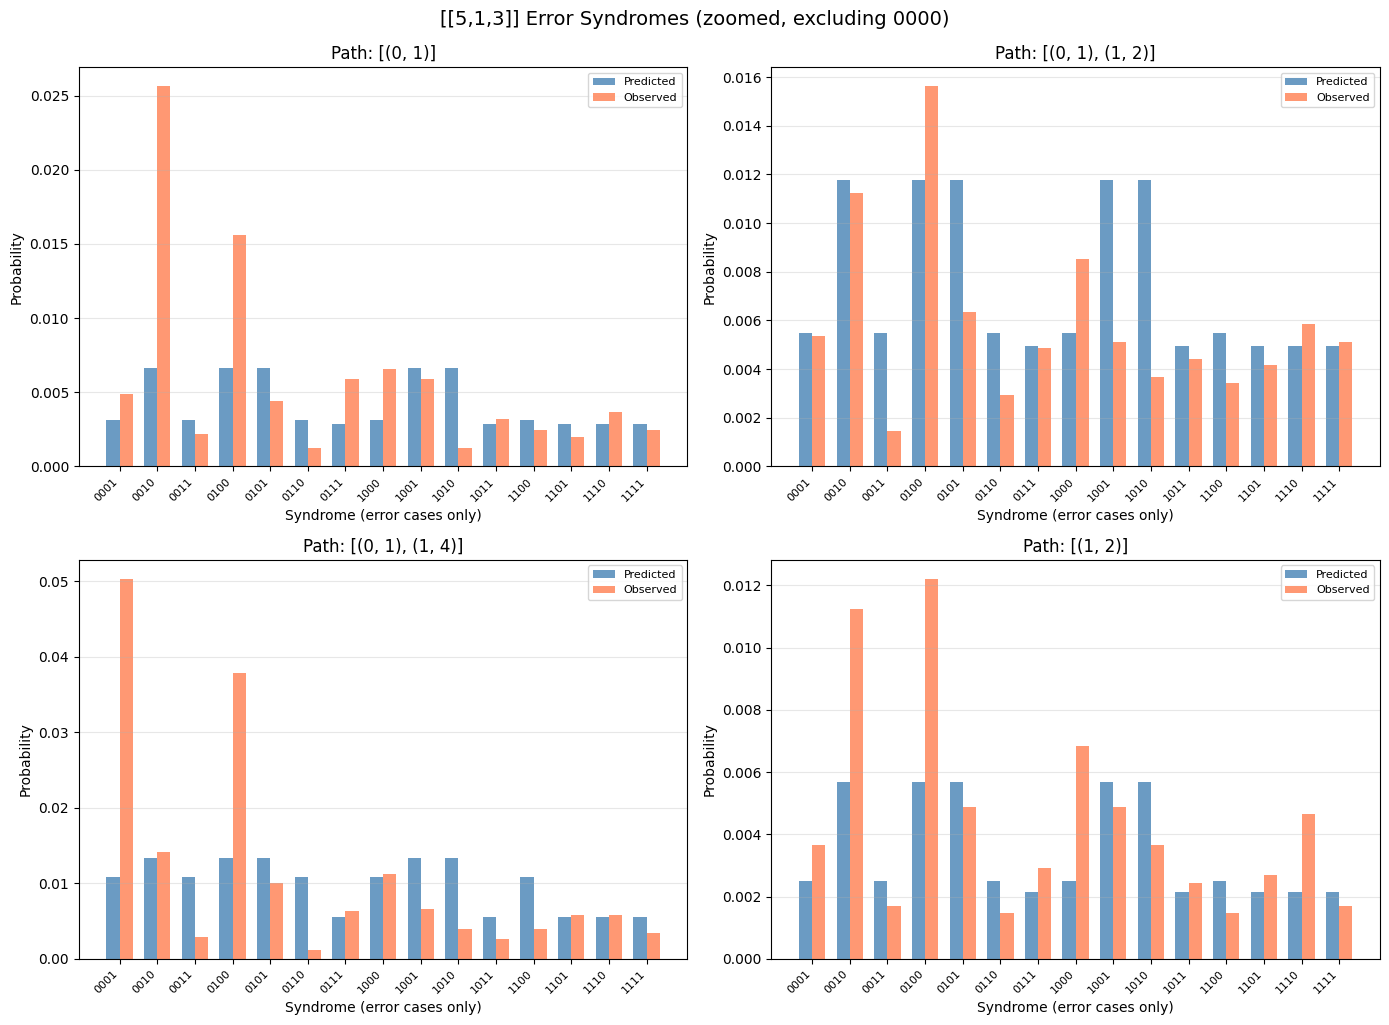

In [13]:
# ============================================================
# ZOOMED VIEW: ERROR SYNDROMES ONLY (excluding 0000)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_errors = np.arange(1, 16)  # Syndromes 1-15 (excluding 0000)
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    # Plot only error syndromes (1-15)
    bars1 = ax.bar(x_errors - width/2, predicted_probs[1:], width, label='Predicted', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x_errors + width/2, observed_probs[1:], width, label='Observed', color='coral', alpha=0.8)
    
    ax.set_xlabel('Syndrome (error cases only)')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}')
    ax.set_xticks(x_errors)
    ax.set_xticklabels(SYNDROME_LABELS[1:], rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('[[5,1,3]] Error Syndromes (zoomed, excluding 0000)', fontsize=14, y=1.02)
plt.show()

In [14]:
# ============================================================
# OVERALL PREDICTION QUALITY METRICS
# ============================================================

def total_variation_distance(p, q):
    """Total Variation Distance: 0.5 * sum(|p_i - q_i|)"""
    return 0.5 * np.sum(np.abs(p - q))

def kl_divergence(p, q, epsilon=1e-10):
    """KL Divergence: sum(p * log(p/q))"""
    p = np.clip(p, epsilon, 1)
    q = np.clip(q, epsilon, 1)
    return np.sum(p * np.log(p / q))

def hellinger_distance(p, q):
    """Hellinger Distance: sqrt(1 - sum(sqrt(p_i * q_i)))"""
    return np.sqrt(1 - np.sum(np.sqrt(p * q)))

metrics_by_hops = {1: [], 2: []}

for measurement in measurements:
    path_edges = measurement.path_edges
    num_hops = len(path_edges)
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_513(
        path_edges=path_edges,
        params=params_for_prediction,
        num_shots=NUM_SHOTS,
        exact=True
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    tvd = total_variation_distance(predicted_probs, observed_probs)
    mse = np.mean((predicted_probs - observed_probs)**2)
    kl = kl_divergence(observed_probs, predicted_probs)
    hellinger = hellinger_distance(predicted_probs, observed_probs)
    
    if num_hops in metrics_by_hops:
        metrics_by_hops[num_hops].append({
            'tvd': tvd, 'mse': mse, 'kl': kl, 'hellinger': hellinger
        })

print("=" * 70)
print("[[5,1,3]] OVERALL PREDICTION QUALITY METRICS")
print(f"Using {params_source} parameters")
print("=" * 70)

for num_hops, metrics_list in metrics_by_hops.items():
    if not metrics_list:
        continue
    print(f"\n{num_hops}-Hop Paths ({len(metrics_list)} measurements):")
    tvds = [m['tvd'] for m in metrics_list]
    mses = [m['mse'] for m in metrics_list]
    kls = [m['kl'] for m in metrics_list]
    hellingers = [m['hellinger'] for m in metrics_list]
    
    print(f"  TVD:       {np.mean(tvds):.4f} ± {np.std(tvds):.4f}")
    print(f"  MSE:       {np.mean(mses):.6f} ± {np.std(mses):.6f}")
    print(f"  KL Div:    {np.mean(kls):.4f} ± {np.std(kls):.4f}")
    print(f"  Hellinger: {np.mean(hellingers):.4f} ± {np.std(hellingers):.4f}")

# Overall metrics
all_metrics = [m for metrics in metrics_by_hops.values() for m in metrics]
print(f"\n{'='*70}")
print(f"OVERALL ({len(all_metrics)} measurements):")
print(f"  Mean TVD:       {np.mean([m['tvd'] for m in all_metrics]):.4f}")
print(f"  Mean MSE:       {np.mean([m['mse'] for m in all_metrics]):.6f}")
print(f"  Mean KL Div:    {np.mean([m['kl'] for m in all_metrics]):.4f}")
print(f"  Mean Hellinger: {np.mean([m['hellinger'] for m in all_metrics]):.4f}")

print("\n" + "-" * 70)
print("Interpretation:")
print("  TVD (Total Variation Distance): 0 = identical, 1 = completely different")
print("  MSE (Mean Squared Error): Lower is better")
print("  KL (KL Divergence): 0 = identical, higher = more different")
print("  Hellinger: 0 = identical, 1 = completely different")

[[5,1,3]] OVERALL PREDICTION QUALITY METRICS
Using Inferred parameters

1-Hop Paths (7 measurements):
  TVD:       0.0485 ± 0.0159
  MSE:       0.000141 ± 0.000089
  KL Div:    0.0516 ± 0.0274
  Hellinger: 0.1018 ± 0.0301

2-Hop Paths (10 measurements):
  TVD:       0.0614 ± 0.0133
  MSE:       0.000152 ± 0.000069
  KL Div:    0.0530 ± 0.0186
  Hellinger: 0.1138 ± 0.0211

OVERALL (17 measurements):
  Mean TVD:       0.0561
  Mean MSE:       0.000147
  Mean KL Div:    0.0524
  Mean Hellinger: 0.1089

----------------------------------------------------------------------
Interpretation:
  TVD (Total Variation Distance): 0 = identical, 1 = completely different
  MSE (Mean Squared Error): Lower is better
  KL (KL Divergence): 0 = identical, higher = more different
  Hellinger: 0 = identical, 1 = completely different


In [15]:
# ============================================================
# COMPARE GROUND TRUTH VS INFERRED PARAMETERS
# ============================================================

if inferred_params:
    print("Comparing Ground Truth vs Inferred Parameters:")
    print("=" * 70)
    
    comparison_data = []
    for edge in ground_truth_normalized.keys():
        gt = ground_truth_normalized[edge]
        inf = inferred_params.get(edge, {})
        
        comparison_data.append({
            'Edge': str(edge),
            'GT px': gt['px'],
            'Inf px': inf.get('px', np.nan),
            'GT py': gt['py'],
            'Inf py': inf.get('py', np.nan),
            'GT pz': gt['pz'],
            'Inf pz': inf.get('pz', np.nan),
            'px diff': inf.get('px', 0) - gt['px'],
            'py diff': inf.get('py', 0) - gt['py'],
            'pz diff': inf.get('pz', 0) - gt['pz'],
        })
    
    df_gt_vs_inf = pd.DataFrame(comparison_data)
    
    styled_gt_inf = (df_gt_vs_inf
        .style
        .format({col: '{:.5f}' for col in df_gt_vs_inf.columns if col != 'Edge'})
        .set_caption('Ground Truth vs Inferred Pauli Error Rates')
        .background_gradient(subset=['px diff', 'py diff', 'pz diff'], cmap='RdYlGn_r', vmin=-0.01, vmax=0.01)
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
        ])
    )
    
    display(styled_gt_inf)
else:
    print("No inferred parameters available for comparison.")

Comparing Ground Truth vs Inferred Parameters:


,Edge,GT px,Inf px,GT py,Inf py,GT pz,Inf pz,px diff,py diff,pz diff
0,"(0, 1)",0.00732,0.00315,0.00854,0.00291,0.00391,0.00689,-0.00417,-0.00563,0.00298
1,"(0, 3)",0.00562,0.00671,0.00317,0.00199,0.00781,0.00551,0.00110,-0.00118,-0.00230
2,"(1, 2)",0.00671,0.00252,0.00769,0.00215,0.00598,0.00586,-0.00420,-0.00554,-0.00012
3,"(1, 4)",0.00574,0.00853,0.00378,0.00268,0.00720,0.00780,0.00279,-0.00110,0.00060
4,"(2, 5)",0.01697,0.00568,0.01404,0.00215,0.01160,0.01187,-0.01129,-0.01189,0.00027
5,"(3, 4)",0.00464,0.00715,0.00513,0.00377,0.00879,0.00863,0.00251,-0.00136,-0.00016
6,"(4, 5)",0.01477,0.00301,0.01160,0.00177,0.01892,0.01229,-0.01176,-0.00982,-0.00663


In [16]:
# ============================================================
# SYNDROME PATTERN ANALYSIS
# ============================================================
# Analyze which syndromes are most common across all measurements

# Aggregate all syndrome counts
total_syndrome_counts = np.zeros(16)
for measurement in measurements:
    total_syndrome_counts += measurement.histogram

total_syndrome_probs = total_syndrome_counts / np.sum(total_syndrome_counts)

# Create DataFrame for analysis
syndrome_analysis = []
for i in range(16):
    # Determine which single-qubit errors map to this syndrome
    error_sources = []
    for error in ['X', 'Y', 'Z']:
        for qubit in range(5):
            if SYNDROME_TABLE_513[(error, qubit)] == i:
                error_sources.append(f"{error}{qubit}")
    
    syndrome_analysis.append({
        'Syndrome': SYNDROME_LABELS[i],
        'Decimal': i,
        'Count': int(total_syndrome_counts[i]),
        'Probability': total_syndrome_probs[i],
        'Error Sources': ', '.join(error_sources) if error_sources else 'No single error',
    })

df_syndrome = pd.DataFrame(syndrome_analysis)

styled_syndrome = (df_syndrome
    .style
    .format({'Probability': '{:.4f}', 'Count': '{:,.0f}'})
    .set_caption('[[5,1,3]] Syndrome Distribution (Aggregated Across All Measurements)')
    .background_gradient(subset=['Probability'], cmap='Blues')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('padding', '8px')]},
    ])
)

display(styled_syndrome)

,Syndrome,Decimal,Count,Probability,Error Sources
0,0000,0,"61,223",0.8792,No single error
1,0001,1,"1,501",0.0216,X1
2,0010,2,"1,818",0.0261,Z4
3,0011,3,151,0.0022,X2
4,0100,4,"1,324",0.0190,Z2
5,0101,5,409,0.0059,Z0
6,0110,6,132,0.0019,X3
7,0111,7,282,0.0040,Y2
8,1000,8,754,0.0108,X0
9,1001,9,388,0.0056,Z3


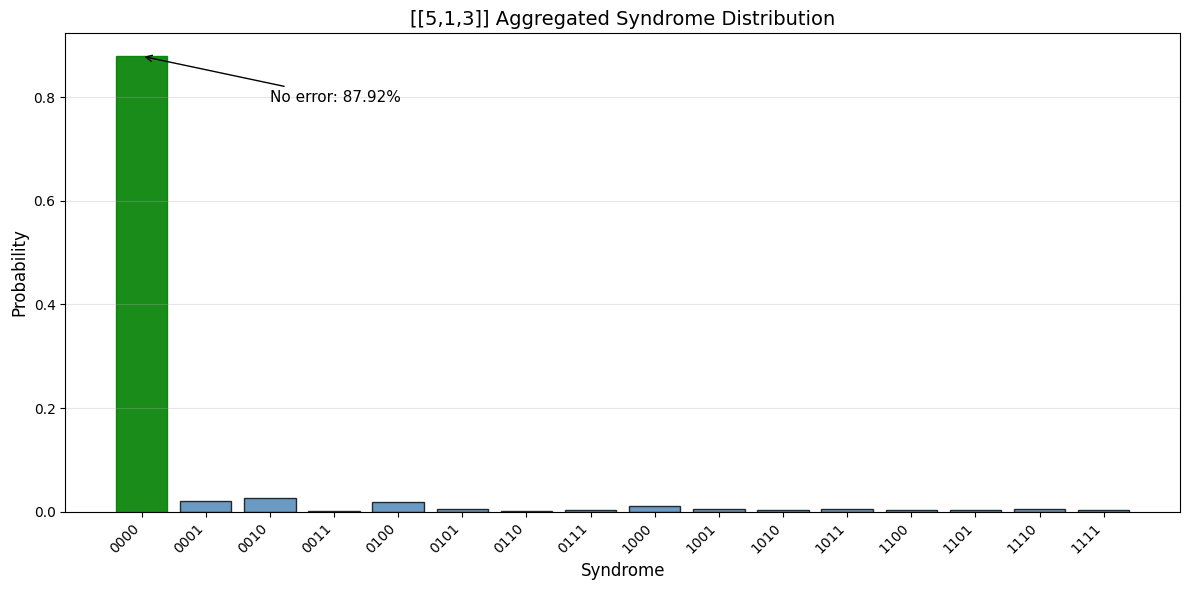


Total measurements: 17
Total shots: 69,632
Overall no-error rate: 87.92%
Overall error rate: 12.08%


In [17]:
# ============================================================
# FINAL VISUALIZATION: Aggregated Syndrome Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(16)
bars = ax.bar(x, total_syndrome_probs, color='steelblue', edgecolor='black', alpha=0.8)

# Highlight the no-error syndrome
bars[0].set_color('green')
bars[0].set_alpha(0.9)

ax.set_xlabel('Syndrome', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('[[5,1,3]] Aggregated Syndrome Distribution', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add annotation for no-error probability
ax.annotate(f'No error: {total_syndrome_probs[0]:.2%}', 
            xy=(0, total_syndrome_probs[0]), 
            xytext=(2, total_syndrome_probs[0] * 0.9),
            fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print(f"\nTotal measurements: {len(measurements)}")
print(f"Total shots: {int(np.sum(total_syndrome_counts)):,}")
print(f"Overall no-error rate: {total_syndrome_probs[0]:.2%}")
print(f"Overall error rate: {1 - total_syndrome_probs[0]:.2%}")